Training SVM with Significant...

SVM - Metrics:
CV Accuracy: 0.9541
Test Accuracy: 0.9777


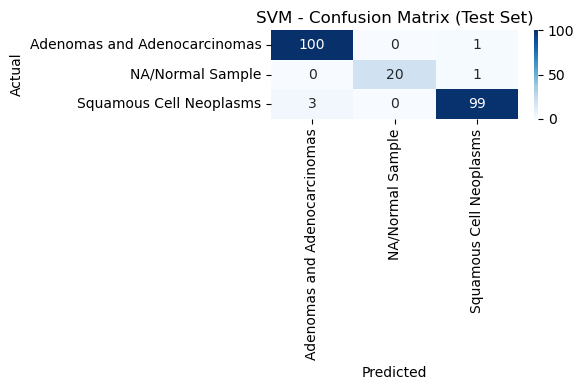

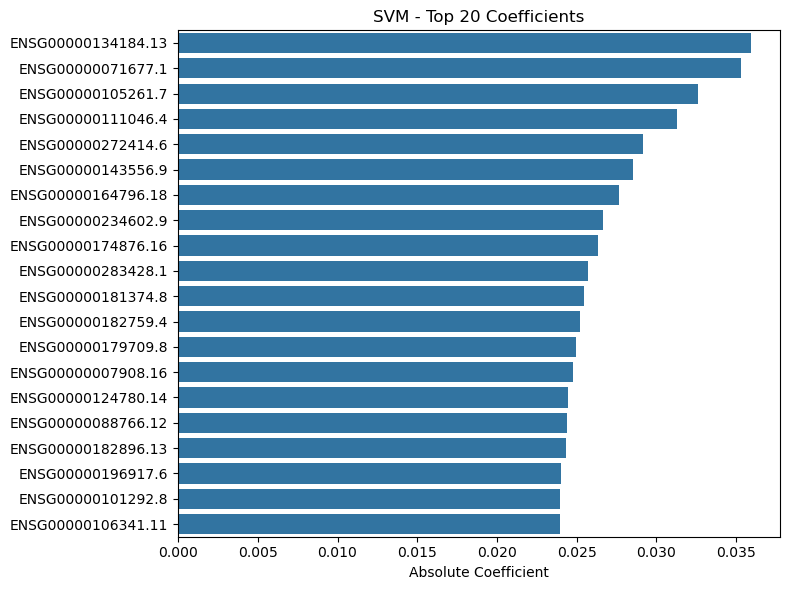

Training LogisticRegression with Significant...

LogisticRegression - Metrics:
CV Accuracy: 0.9530
Test Accuracy: 0.9732


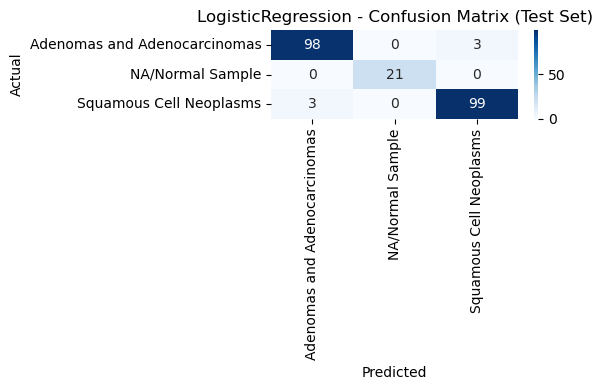

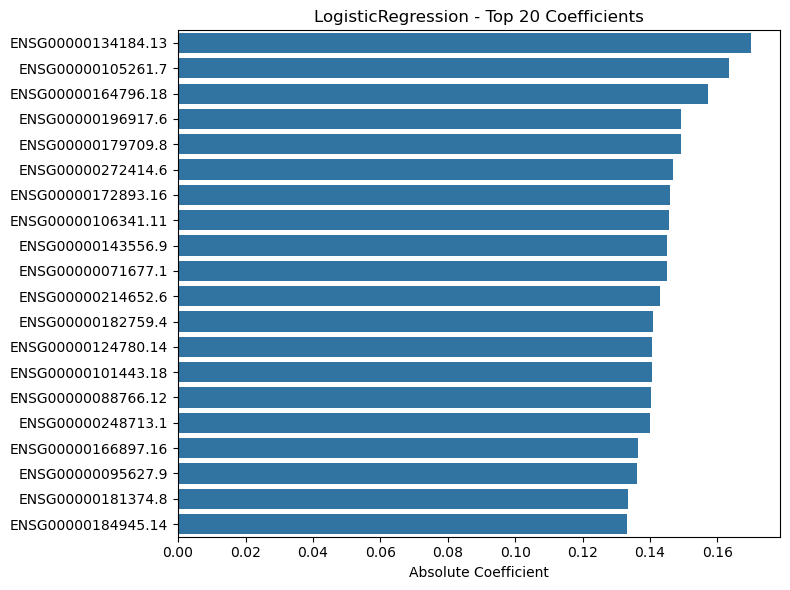

Training XGBoost with Significant...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:21:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:21:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:21:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9777


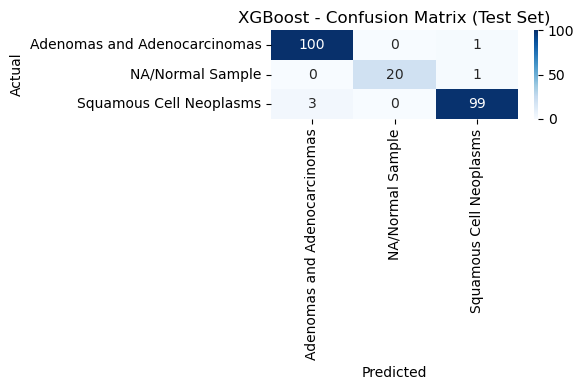

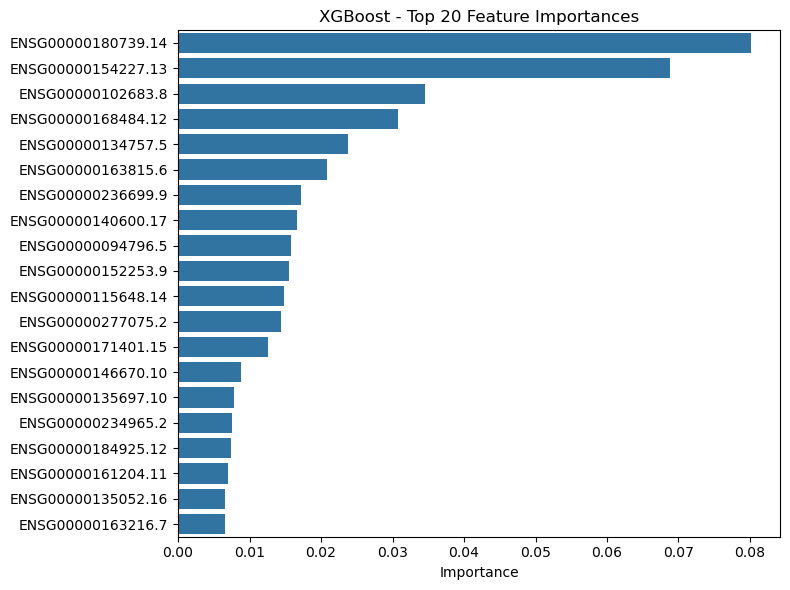

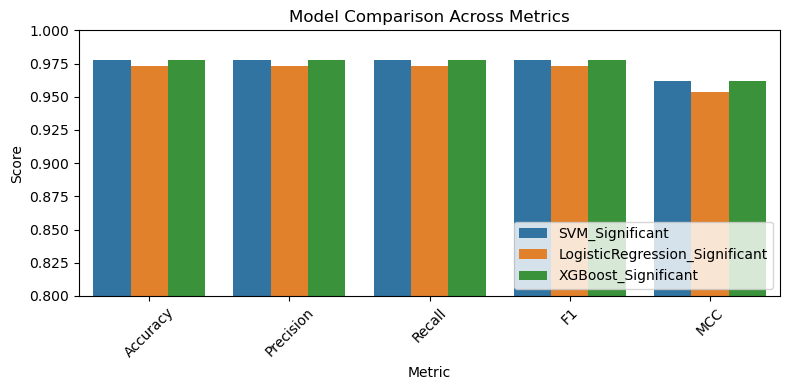

Genes common to all 3 models:
No common genes found


Genes common to pairs:

SVM & LogisticRegression:
{'ENSG00000181374.8', 'ENSG00000179709.8', 'ENSG00000088766.12', 'ENSG00000272414.6', 'ENSG00000182759.4', 'ENSG00000134184.13', 'ENSG00000106341.11', 'ENSG00000071677.1', 'ENSG00000164796.18', 'ENSG00000196917.6', 'ENSG00000124780.14', 'ENSG00000143556.9', 'ENSG00000105261.7'}

SVM & XGBoost:
No shared genes

LogisticRegression & XGBoost:
No shared genes


In [3]:
# Training with just the significant genes - corrected fit.transform, SVM included

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ----------------------- 1. Preprocessing -----------------------
def preprocess_data(df, label_col='cases.disease_type', scaler=None, fit_scaler=True):
    y = df[label_col]
    X = df.drop(columns=[label_col])

    X_log = np.log1p(X)

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_scaled = scaler.fit_transform(X_log)
    else:
        X_scaled = scaler.transform(X_log)

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    return X_scaled, y_encoded, scaler, label_encoder

# ----------------------- 2. Feature Selection -----------------------
def select_significant_genes(df, gene_list):
    all_genes = df.columns.drop('cases.disease_type')
    return [gene for gene in gene_list if gene in all_genes]

# ----------------------- 3. Training & Evaluation -----------------------
def evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names=None):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    def get_metrics(y_true, y_pred):
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'ConfusionMatrix': confusion_matrix(y_true, y_pred)
        }

    results = {
        'CV': get_metrics(y_train, y_pred_cv),
        'Test': get_metrics(y_test, y_pred_test)
    }
    # print the accuracy scores for each model
    print(f"\n{name} - Metrics:")
    print(f"CV Accuracy: {results['CV']['Accuracy']:.4f}")
    print(f"Test Accuracy: {results['Test']['Accuracy']:.4f}")
    

    cm = results['Test']['ConfusionMatrix']
    decoded_labels = label_encoder.inverse_transform(np.unique(y_test))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=decoded_labels, yticklabels=decoded_labels)
    plt.title(f'{name} - Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    top_features = []
        # Feature importance plot
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-20:][::-1]  # Top 20
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Feature Importances')
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()
        
    elif hasattr(model, 'coef_') and feature_names is not None:
        importances = np.abs(model.coef_).sum(axis=0)
        indices = np.argsort(importances)[-20:][::-1]
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Coefficients')
        plt.xlabel("Absolute Coefficient")
        plt.tight_layout()
        plt.show()
        top_features = np.array(feature_names)[indices].tolist()

    return results, top_features 

# ----------------------- 4. Gene Overlap Analysis -----------------------
def analyze_gene_overlaps(model_top_genes):
    svm_genes = set(model_top_genes['SVM_Significant'])
    lr_genes = set(model_top_genes['LogisticRegression_Significant'])
    xgb_genes = set(model_top_genes['XGBoost_Significant'])

    common_all = svm_genes & lr_genes & xgb_genes
    print("Genes common to all 3 models:")
    print(common_all if common_all else "No common genes found\n")

    common_pairs = {
        'SVM & LogisticRegression': svm_genes & lr_genes,
        'SVM & XGBoost': svm_genes & xgb_genes,
        'LogisticRegression & XGBoost': lr_genes & xgb_genes
    }

    print("\nGenes common to pairs:")
    for pair, genes in common_pairs.items():
        print(f"\n{pair}:")
        print(genes if genes else "No shared genes")

# ----------------------- 5. Model Training -----------------------
def train_and_evaluate_models(X_train, y_train, X_test, y_test, label_encoder, gene_set_label, feature_names):
    models = {
        'SVM': SVC(kernel='linear', probability=True),
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                 random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    }

    all_results = {}
    model_top_genes = {}
    for name, model in models.items():
        print(f"Training {name} with {gene_set_label}...")
        results, top_genes = evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names)
        all_results[f"{name}_{gene_set_label}"] = results['Test']
        model_top_genes[f"{name}_{gene_set_label}"] = top_genes

    return all_results, model_top_genes

# ----------------------- 6. Pipeline -----------------------
def run_pipeline(train_csv, test_csv, significant_genes_file):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    with open(significant_genes_file, "r") as f:
        sig_gene_list = [line.strip() for line in f]

    sig_genes = select_significant_genes(train_df, sig_gene_list)
    train_sig = train_df[['cases.disease_type'] + sig_genes]
    test_sig = test_df[['cases.disease_type'] + sig_genes]

    X_train_sig, y_train_sig, scaler_sig, le_sig = preprocess_data(train_sig)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig, scaler=scaler_sig, fit_scaler=False)

    results_significant, model_top_genes = train_and_evaluate_models(X_train_sig, y_train_sig, X_test_sig, y_test_sig, le_sig, 'Significant', sig_genes)

    return results_significant, model_top_genes  

# ----------------------- 7. Plot Comparison -----------------------
def plot_comparison(results_significant):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
    df = []

    for model_label, metrics_dict in results_significant.items():
        for metric in metrics:
            df.append({
                'Model': model_label,
                'Metric': metric,
                'Score': metrics_dict[metric]
            })

    df = pd.DataFrame(df)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x='Metric', y='Score', hue='Model')
    plt.title('Model Comparison Across Metrics')
    plt.xticks(rotation=45)
    plt.ylim(0.80, 1.00)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# ----------------------- 8. Run -----------------------
if __name__ == "__main__":
    train_csv = "Data/compiled_train.csv"
    test_csv = "Data/compiled_test.csv"
    sig_genes_file = "Data/intersection_sig_genes.txt"

    results_significant, model_top_genes = run_pipeline(train_csv, test_csv, sig_genes_file)
    plot_comparison(results_significant)
    analyze_gene_overlaps(model_top_genes)


Training SVM with Random3000...

SVM - Metrics:
CV Accuracy: 0.9508
Test Accuracy: 0.9732


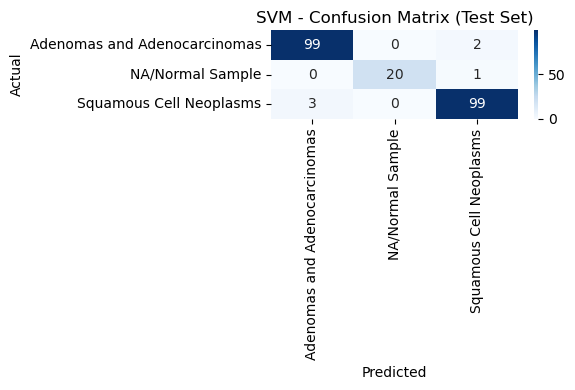

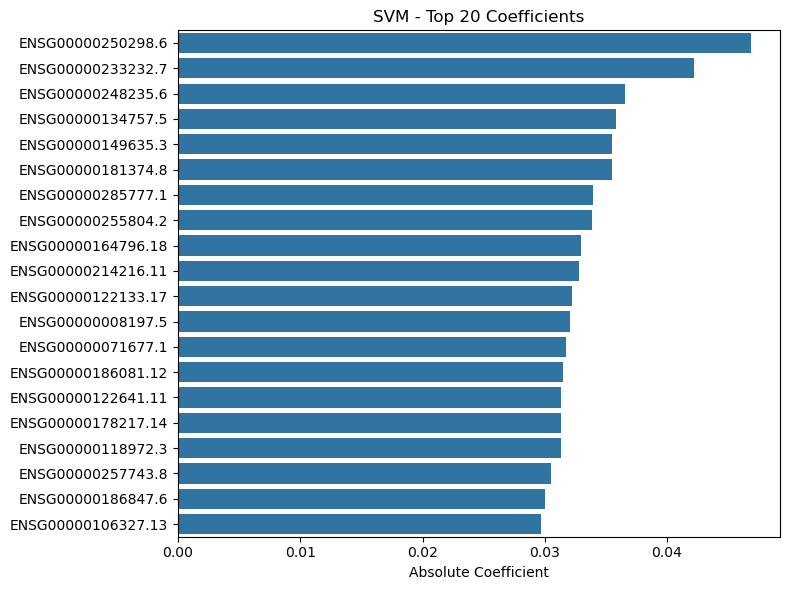

Training LogisticRegression with Random3000...

LogisticRegression - Metrics:
CV Accuracy: 0.9519
Test Accuracy: 0.9866


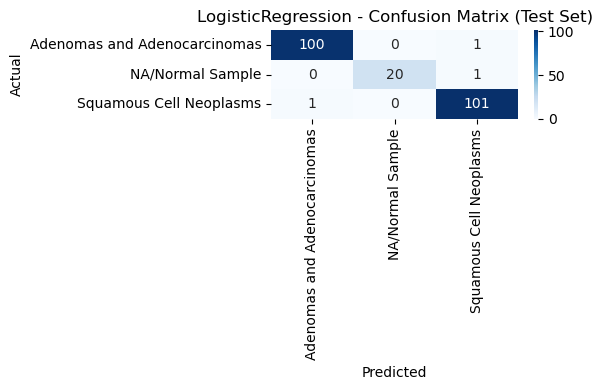

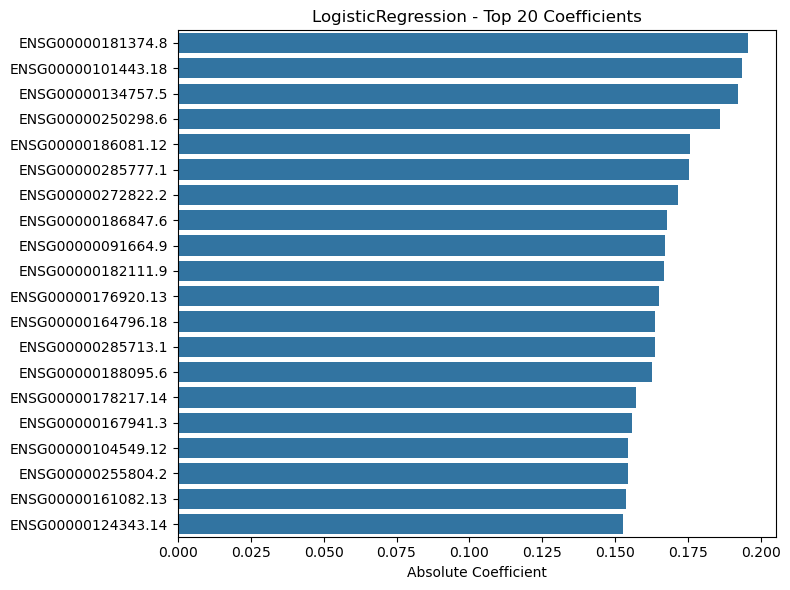

Training XGBoost with Random3000...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:48:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:49:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:49:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9732


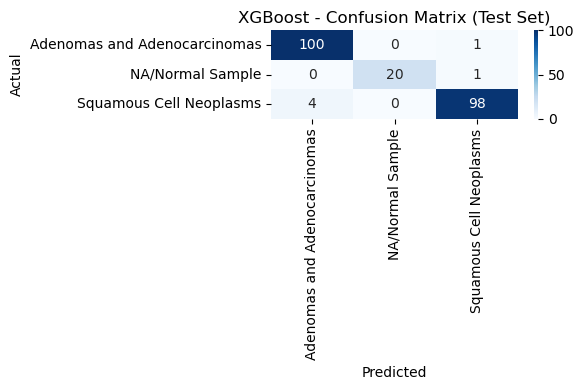

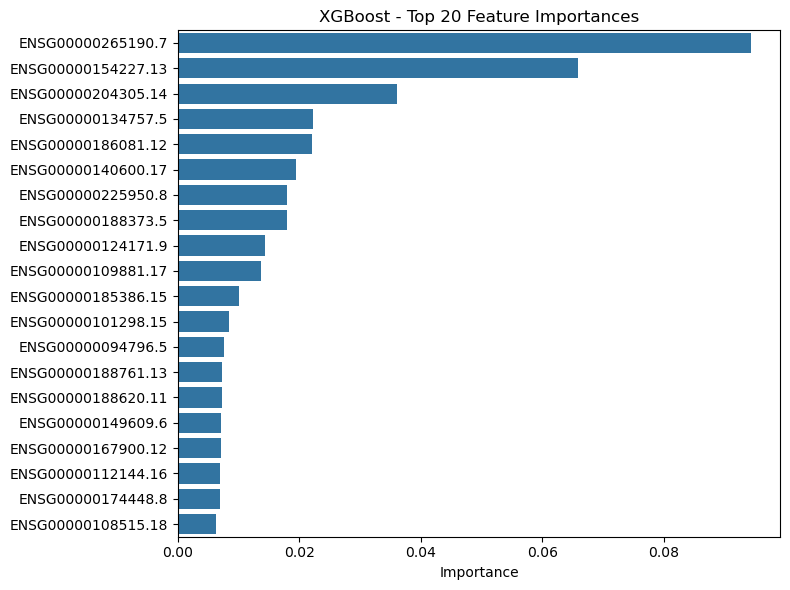

Training SVM with Significant...

SVM - Metrics:
CV Accuracy: 0.9541
Test Accuracy: 0.9777


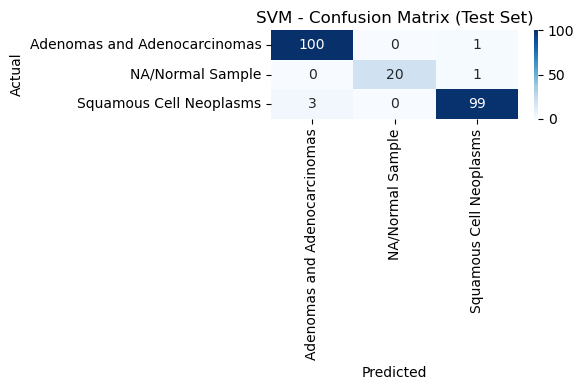

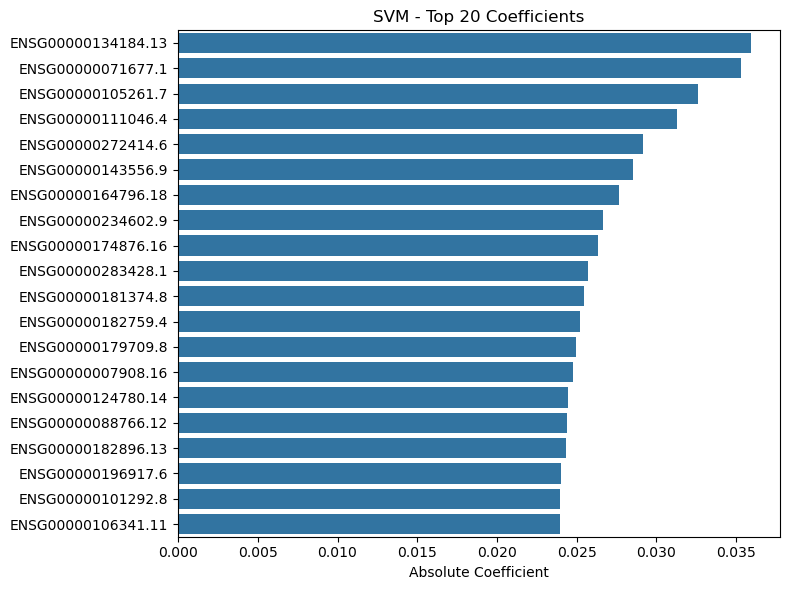

Training LogisticRegression with Significant...

LogisticRegression - Metrics:
CV Accuracy: 0.9530
Test Accuracy: 0.9732


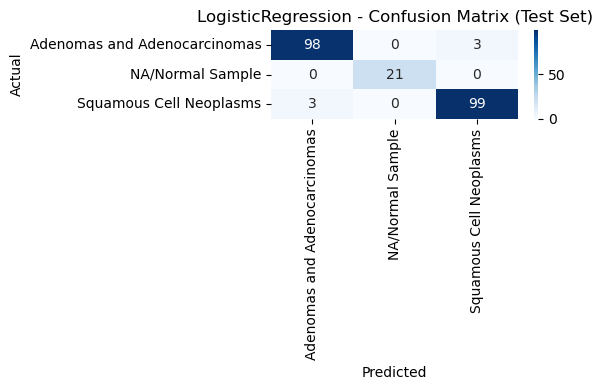

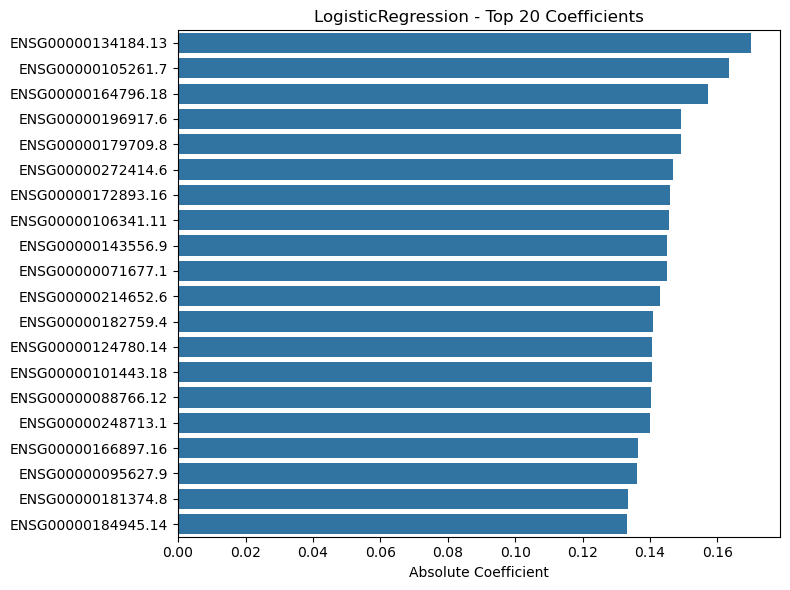

Training XGBoost with Significant...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:51:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:51:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:51:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9777


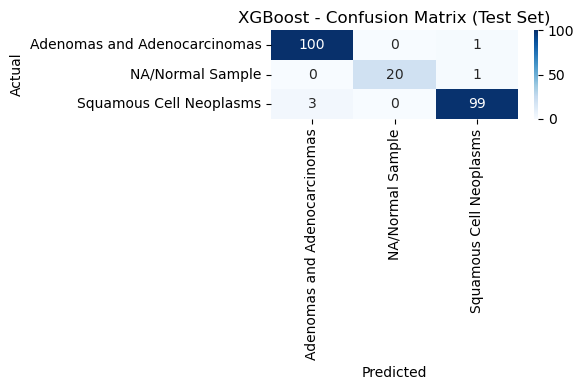

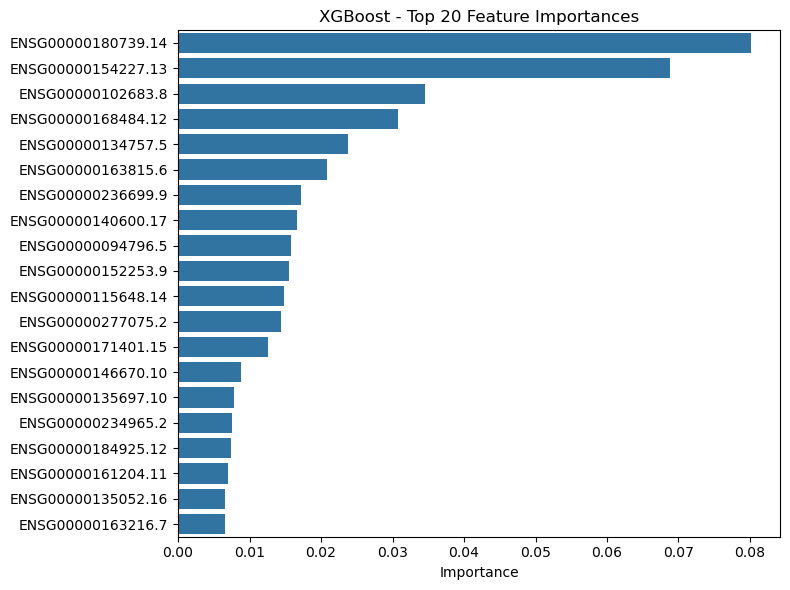

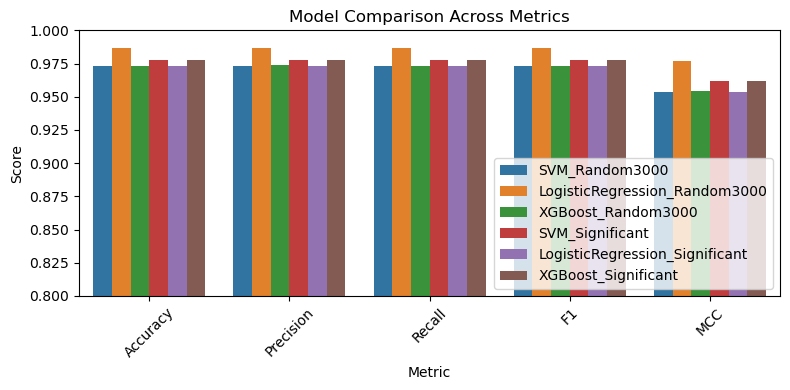

In [5]:
# With cross validation on 3000 random vs significant genes - corrected for fit transform

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ----------------------- 1. Preprocessing -----------------------
def preprocess_data(df, label_col='cases.disease_type', scaler=None, fit_scaler=True):
    y = df[label_col]
    X = df.drop(columns=[label_col])

    X_log = np.log1p(X)

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_scaled = scaler.fit_transform(X_log)
    else:
        X_scaled = scaler.transform(X_log)

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    return X_scaled, y_encoded, scaler, label_encoder

# ----------------------- 2. Feature Selection -----------------------
def select_random_genes(df, num_genes=3000):
    all_genes = df.columns.drop('cases.disease_type')
    return random.sample(list(all_genes), num_genes)

def select_significant_genes(df, gene_list):
    all_genes = df.columns.drop('cases.disease_type')
    return [gene for gene in gene_list if gene in all_genes]

# ----------------------- 3. Training & Evaluation -----------------------
def evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names=None):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validated predictions on training data
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf)

    # Train final model and test on external test set
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    def get_metrics(y_true, y_pred):
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'ConfusionMatrix': confusion_matrix(y_true, y_pred)
        }

    results = {
        'CV': get_metrics(y_train, y_pred_cv),
        'Test': get_metrics(y_test, y_pred_test)
    }

    # Print the accuracy scores for each model
    print(f"\n{name} - Metrics:")   
    print(f"CV Accuracy: {results['CV']['Accuracy']:.4f}")
    print(f"Test Accuracy: {results['Test']['Accuracy']:.4f}")

    # Confusion matrix on test set
    cm = results['Test']['ConfusionMatrix']
    decoded_labels = label_encoder.inverse_transform(np.unique(y_test))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=decoded_labels, yticklabels=decoded_labels)
    plt.title(f'{name} - Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Feature importance plot
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-20:][::-1]  # Top 20
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Feature Importances')
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_') and feature_names is not None:
        # Logistic regression - sum absolute coefficients across classes
        importances = np.abs(model.coef_).sum(axis=0)  # Changed from flatten()
        indices = np.argsort(importances)[-20:][::-1]
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Coefficients')
        plt.xlabel("Absolute Coefficient")
        plt.tight_layout()
        plt.show()

    return results

def train_and_evaluate_models(X_train, y_train, X_test, y_test, label_encoder, gene_set_label, feature_names):
    models = {
        'SVM': SVC(kernel='linear', probability=True),        
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                 random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    }

    all_results = {}
    for name, model in models.items():
        print(f"Training {name} with {gene_set_label}...")
        results = evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names)
        all_results[f"{name}_{gene_set_label}"] = results['Test']  # Save only test results

    return all_results

# ----------------------- 4. Pipeline -----------------------
def run_pipeline(train_csv, test_csv, significant_genes_file):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    with open(significant_genes_file, "r") as f:
        sig_gene_list = [line.strip() for line in f]

    # Random gene set
    rand_genes = select_random_genes(train_df, 3000)
    train_rand = train_df[['cases.disease_type'] + rand_genes]
    test_rand = test_df[['cases.disease_type'] + rand_genes]
    X_train_rand, y_train_rand, _, le_rand = preprocess_data(train_rand)
    X_test_rand, y_test_rand, _, _ = preprocess_data(test_rand)
    results_random = train_and_evaluate_models(X_train_rand, y_train_rand, X_test_rand, y_test_rand, le_rand, 'Random3000', rand_genes)

    # Significant gene set
    sig_genes = select_significant_genes(train_df, sig_gene_list)
    train_sig = train_df[['cases.disease_type'] + sig_genes]
    test_sig = test_df[['cases.disease_type'] + sig_genes]
    # Fit scaler on training data only
    X_train_sig, y_train_sig, scaler_sig, le_sig = preprocess_data(train_sig)
    # Use the same scaler for test data (no fitting)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig, scaler=scaler_sig, fit_scaler=False)
    """ X_train_sig, y_train_sig, _, le_sig = preprocess_data(train_sig)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig)"""
    results_significant = train_and_evaluate_models(X_train_sig, y_train_sig, X_test_sig, y_test_sig, le_sig, 'Significant', sig_genes)

    return results_random, results_significant

# ----------------------- 5. Comparison Plot -----------------------
def plot_comparison(results_random, results_significant):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
    df = []

    for model_label, metrics_dict in {**results_random, **results_significant}.items():
        for metric in metrics:
            df.append({
                'Model': model_label,
                'Metric': metric,
                'Score': metrics_dict[metric]
            })

    df = pd.DataFrame(df)
    plt.figure(figsize=(8, 4))  # Smaller figure
    sns.barplot(data=df, x='Metric', y='Score', hue='Model')
    plt.title('Model Comparison Across Metrics')
    plt.xticks(rotation=45)
    plt.ylim(0.80, 1.00)  # Zoom in on the top
    plt.legend(loc='lower right')  # Legend in bottom right
    plt.tight_layout()
    plt.show()
    
# ----------------------- 6. Run everything -----------------------
if __name__ == "__main__":
    train_csv = "Data/compiled_train.csv"
    test_csv = "Data/compiled_test.csv"
    sig_genes_file = "Data/intersection_sig_genes.txt"

    results_random, results_significant = run_pipeline(train_csv, test_csv, sig_genes_file)
    plot_comparison(results_random, results_significant)


cases.disease_type
Squamous Cell Neoplasms         0.456376
Adenomas and Adenocarcinomas    0.444072
NA/Normal Sample                0.099553
Name: proportion, dtype: float64
cases.disease_type
Squamous Cell Neoplasms         0.455357
Adenomas and Adenocarcinomas    0.450893
NA/Normal Sample                0.093750
Name: proportion, dtype: float64
Training SVM with Random3000...

SVM - Metrics:
CV Accuracy: 0.7785
Test Accuracy: 0.8259


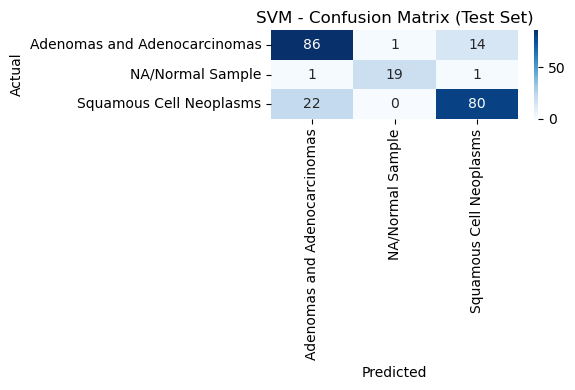

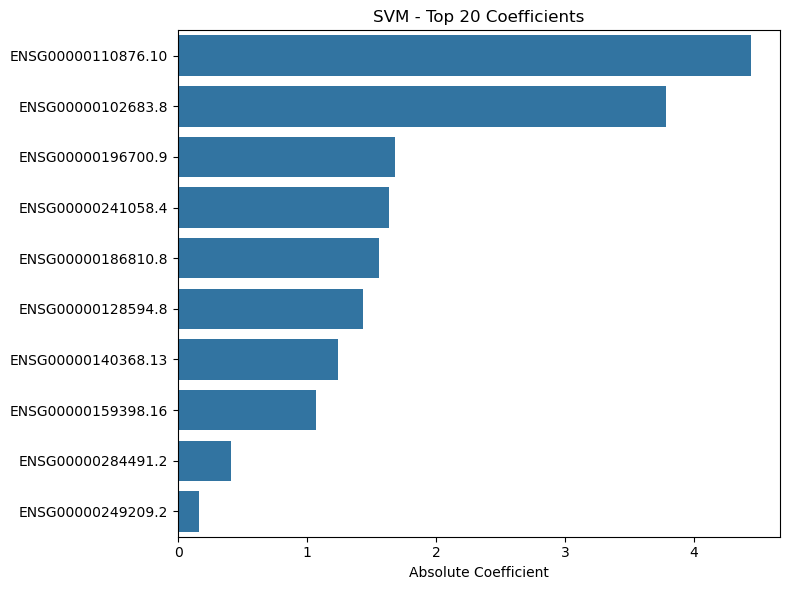

Training LogisticRegression with Random3000...

LogisticRegression - Metrics:
CV Accuracy: 0.7774
Test Accuracy: 0.8170


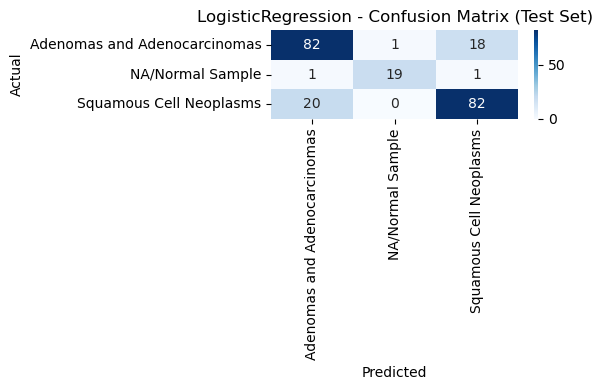

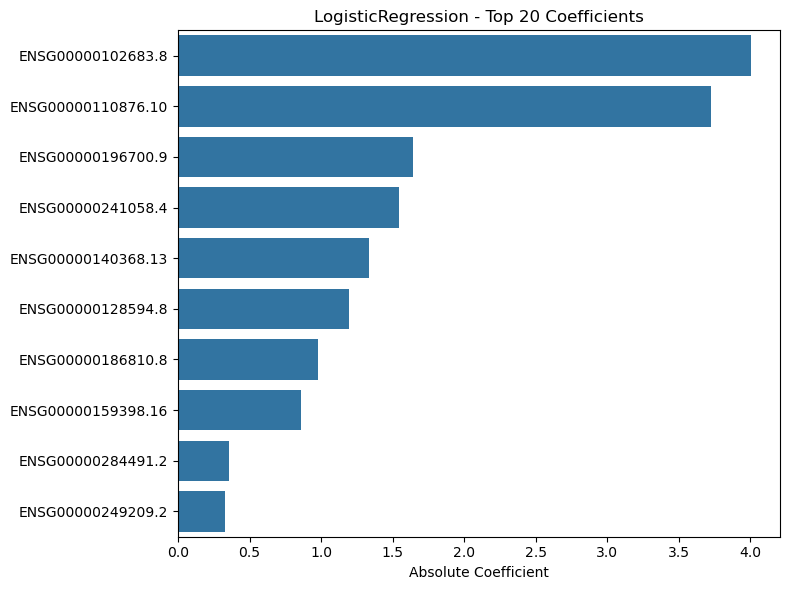

Training XGBoost with Random3000...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost - Metrics:
CV Accuracy: 0.7774
Test Accuracy: 0.8125


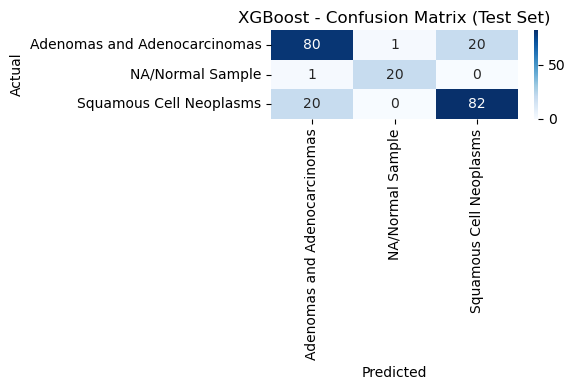

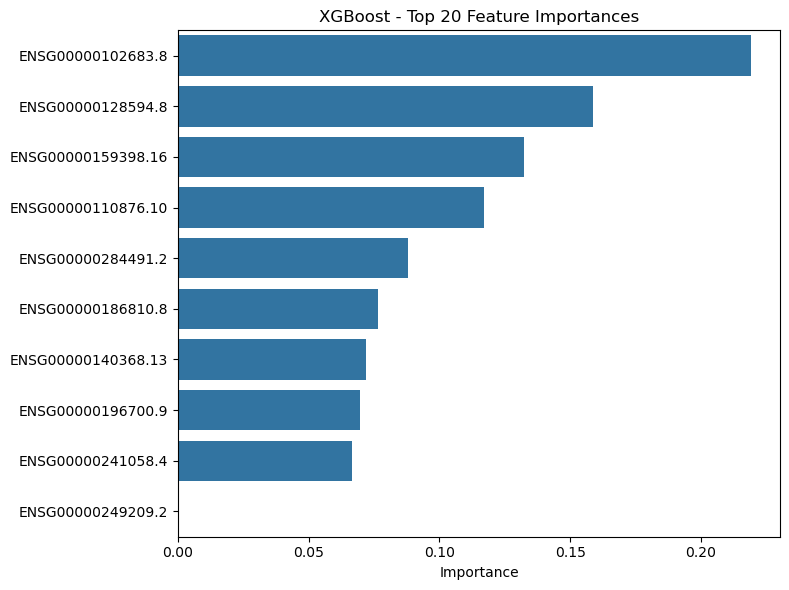

Training SVM with Significant...

SVM - Metrics:
CV Accuracy: 0.9541
Test Accuracy: 0.9777


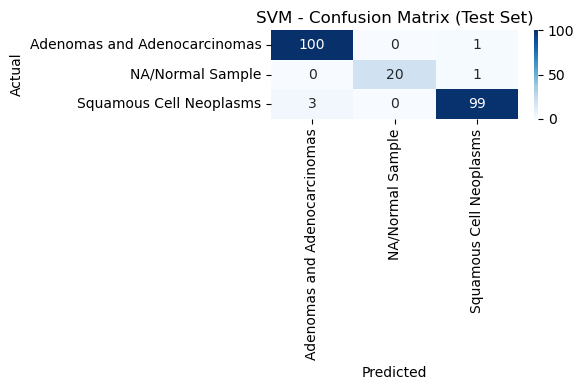

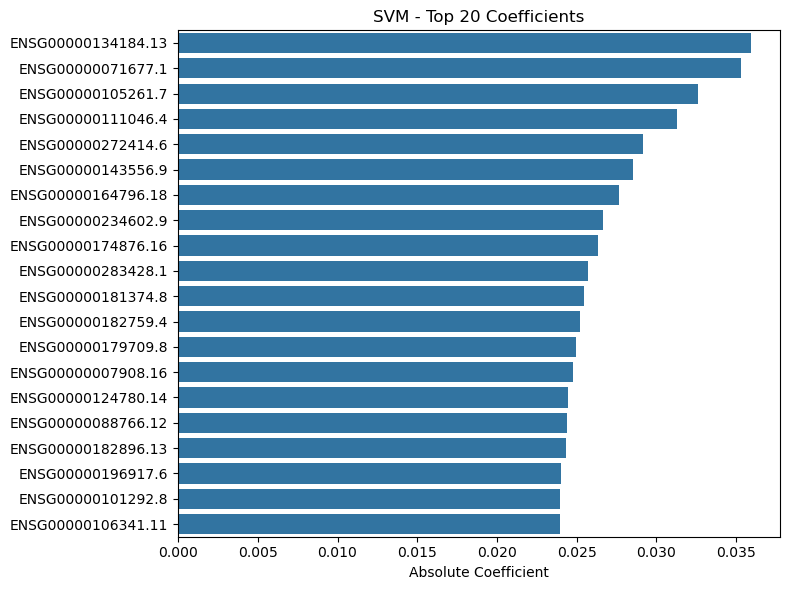

Training LogisticRegression with Significant...

LogisticRegression - Metrics:
CV Accuracy: 0.9530
Test Accuracy: 0.9732


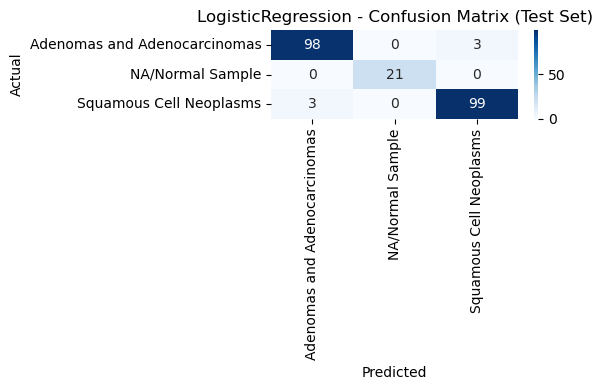

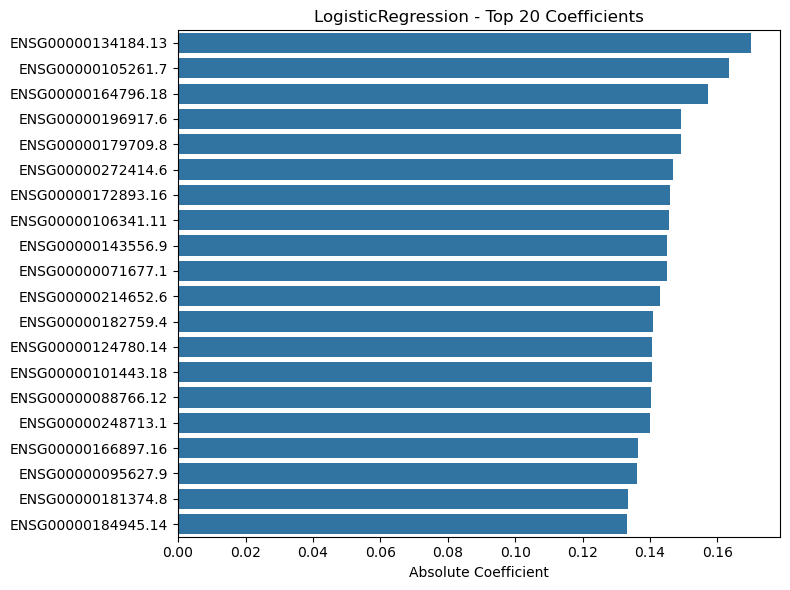

Training XGBoost with Significant...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9777


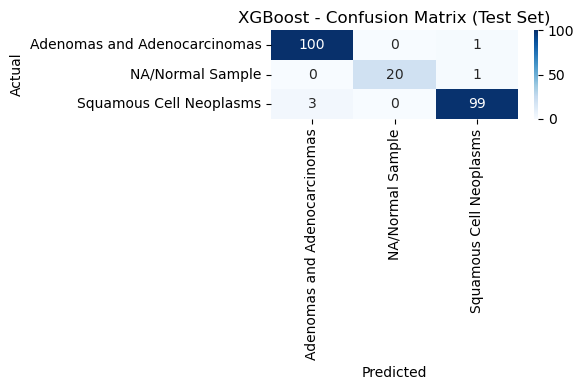

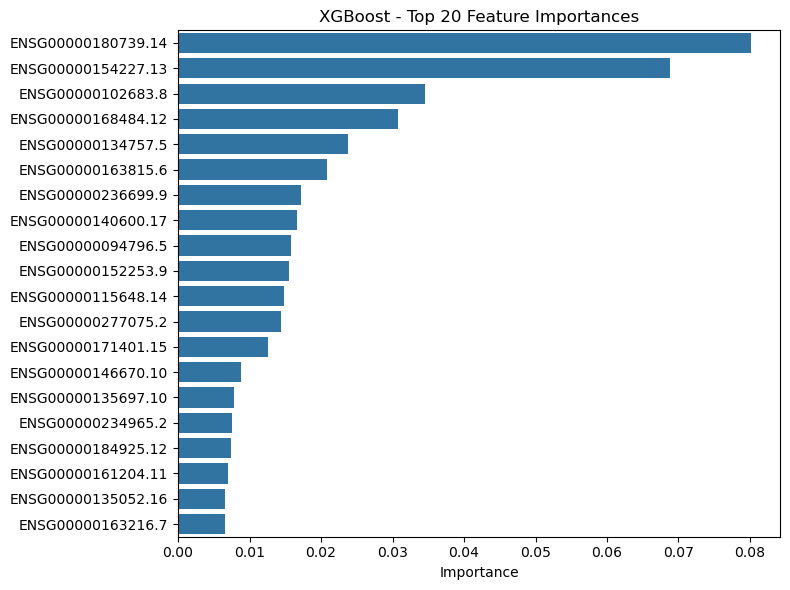

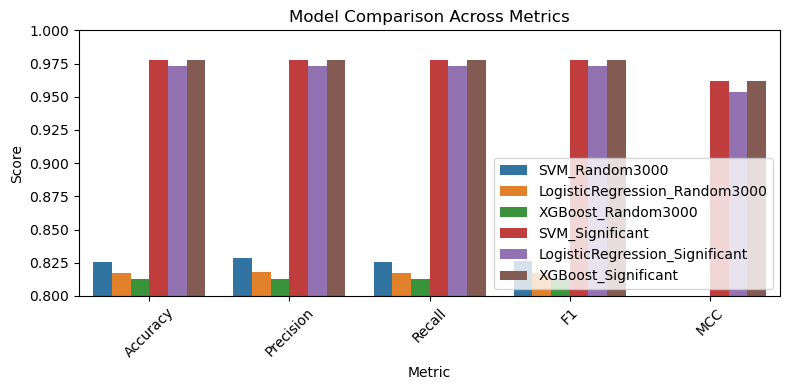

In [ ]:
# With cross validation on 3000 random vs significant genes - corrected for fit transform

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ----------------------- 1. Preprocessing -----------------------
def preprocess_data(df, label_col='cases.disease_type', scaler=None, fit_scaler=True):
    y = df[label_col]
    X = df.drop(columns=[label_col])

    X_log = np.log1p(X)

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_scaled = scaler.fit_transform(X_log)
    else:
        X_scaled = scaler.transform(X_log)

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    return X_scaled, y_encoded, scaler, label_encoder

# ----------------------- 2. Feature Selection -----------------------
def select_random_genes(df, num_genes=10, seed=42):
    all_genes = df.columns.drop('cases.disease_type')
    return random.sample(list(all_genes), num_genes)

def select_significant_genes(df, gene_list):
    all_genes = df.columns.drop('cases.disease_type')
    return [gene for gene in gene_list if gene in all_genes]

# ----------------------- 3. Training & Evaluation -----------------------
def evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names=None):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validated predictions on training data
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf)

    # Train final model and test on external test set
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    def get_metrics(y_true, y_pred):
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'ConfusionMatrix': confusion_matrix(y_true, y_pred)
        }

    results = {
        'CV': get_metrics(y_train, y_pred_cv),
        'Test': get_metrics(y_test, y_pred_test)
    }

    # Print the accuracy scores for each model
    print(f"\n{name} - Metrics:")   
    print(f"CV Accuracy: {results['CV']['Accuracy']:.4f}")
    print(f"Test Accuracy: {results['Test']['Accuracy']:.4f}")

    # Confusion matrix on test set
    cm = results['Test']['ConfusionMatrix']
    decoded_labels = label_encoder.inverse_transform(np.unique(y_test))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=decoded_labels, yticklabels=decoded_labels)
    plt.title(f'{name} - Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Feature importance plot
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-20:][::-1]  # Top 20
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Feature Importances')
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_') and feature_names is not None:
        # Logistic regression - sum absolute coefficients across classes
        importances = np.abs(model.coef_).sum(axis=0)  # Changed from flatten()
        indices = np.argsort(importances)[-20:][::-1]
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Coefficients')
        plt.xlabel("Absolute Coefficient")
        plt.tight_layout()
        plt.show()

    return results

def train_and_evaluate_models(X_train, y_train, X_test, y_test, label_encoder, gene_set_label, feature_names):
    models = {
        'SVM': SVC(kernel='linear', probability=True),        
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                 random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    }

    all_results = {}
    for name, model in models.items():
        print(f"Training {name} with {gene_set_label}...")
        results = evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names)
        all_results[f"{name}_{gene_set_label}"] = results['Test']  # Save only test results

    return all_results

# ----------------------- 4. Pipeline -----------------------
def run_pipeline(train_csv, test_csv, significant_genes_file):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    with open(significant_genes_file, "r") as f:
        sig_gene_list = [line.strip() for line in f]
    print(train_df['cases.disease_type'].value_counts(normalize=True))
    print(test_df['cases.disease_type'].value_counts(normalize=True))
    #common = pd.merge(train_df, test_df, on='Unnamed: 0', how='inner')
    #print(f"Overlap rows: {len(common)}")


    # Random gene set
    rand_genes = select_random_genes(train_df, 10)
    train_rand = train_df[['cases.disease_type'] + rand_genes]
    test_rand = test_df[['cases.disease_type'] + rand_genes]
    #X_train_rand, y_train_rand, _, le_rand = preprocess_data(train_rand)
    #X_test_rand, y_test_rand, _, _ = preprocess_data(test_rand)
    # Fit scaler on training data only
    X_train_rand, y_train_rand, scaler_rand, le_rand = preprocess_data(train_rand)
    # Use the same scaler for test data (no fitting)
    X_test_rand, y_test_rand, _, _ = preprocess_data(test_rand, scaler=scaler_rand, fit_scaler=False)
    results_random = train_and_evaluate_models(X_train_rand, y_train_rand, X_test_rand, y_test_rand, le_rand, 'Random10', rand_genes)

    # Significant gene set
    sig_genes = select_significant_genes(train_df, sig_gene_list)
    train_sig = train_df[['cases.disease_type'] + sig_genes]
    test_sig = test_df[['cases.disease_type'] + sig_genes]
    # Fit scaler on training data only
    X_train_sig, y_train_sig, scaler_sig, le_sig = preprocess_data(train_sig)
    # Use the same scaler for test data (no fitting)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig, scaler=scaler_sig, fit_scaler=False)
    """ X_train_sig, y_train_sig, _, le_sig = preprocess_data(train_sig)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig)"""
    results_significant = train_and_evaluate_models(X_train_sig, y_train_sig, X_test_sig, y_test_sig, le_sig, 'Significant', sig_genes)

    return results_random, results_significant

# ----------------------- 5. Comparison Plot -----------------------
def plot_comparison(results_random, results_significant):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
    df = []

    for model_label, metrics_dict in {**results_random, **results_significant}.items():
        for metric in metrics:
            df.append({
                'Model': model_label,
                'Metric': metric,
                'Score': metrics_dict[metric]
            })

    df = pd.DataFrame(df)
    plt.figure(figsize=(8, 4))  # Smaller figure
    sns.barplot(data=df, x='Metric', y='Score', hue='Model')
    plt.title('Model Comparison Across Metrics')
    plt.xticks(rotation=45)
    plt.ylim(0.80, 1.00)  # Zoom in on the top
    plt.legend(loc='lower right')  # Legend in bottom right
    plt.tight_layout()
    plt.show()
    
# ----------------------- 6. Run everything -----------------------
if __name__ == "__main__":
    train_csv = "Data/compiled_train.csv"
    test_csv = "Data/compiled_test.csv"
    sig_genes_file = "Data/intersection_sig_genes.txt"

    results_random, results_significant = run_pipeline(train_csv, test_csv, sig_genes_file)
    plot_comparison(results_random, results_significant)


cases.disease_type
Squamous Cell Neoplasms         0.456376
Adenomas and Adenocarcinomas    0.444072
NA/Normal Sample                0.099553
Name: proportion, dtype: float64
cases.disease_type
Squamous Cell Neoplasms         0.455357
Adenomas and Adenocarcinomas    0.450893
NA/Normal Sample                0.093750
Name: proportion, dtype: float64
Training SVM with Random3000...

SVM - Metrics:
CV Accuracy: 0.9441
Test Accuracy: 0.9777


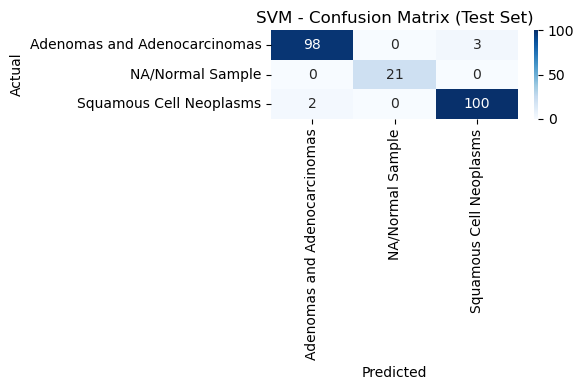

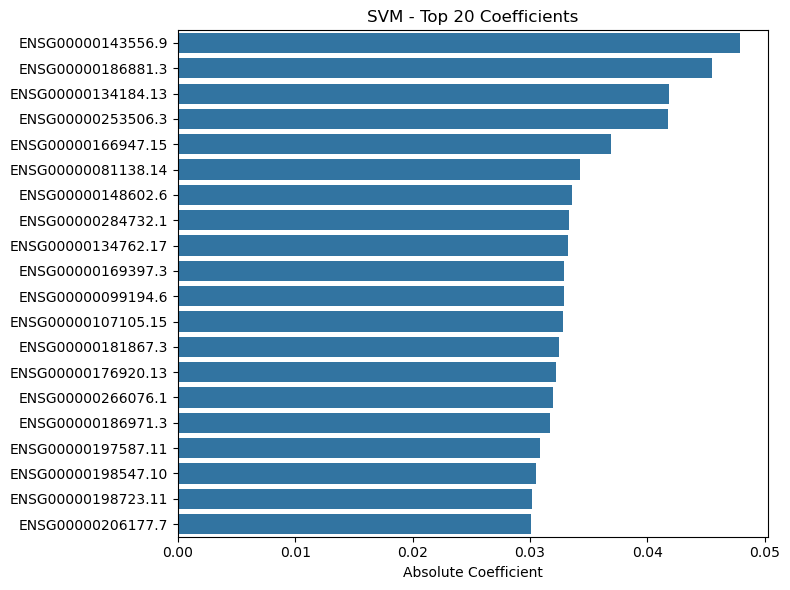

Training LogisticRegression with Random3000...

LogisticRegression - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9777


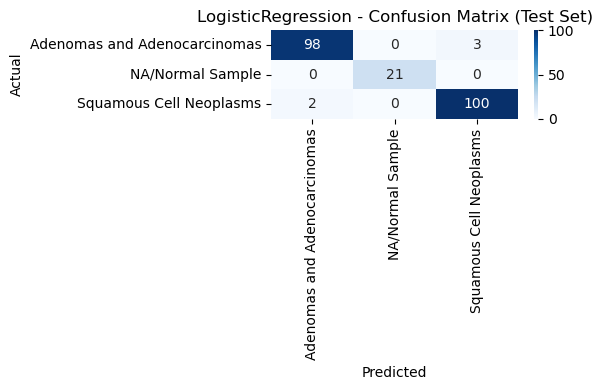

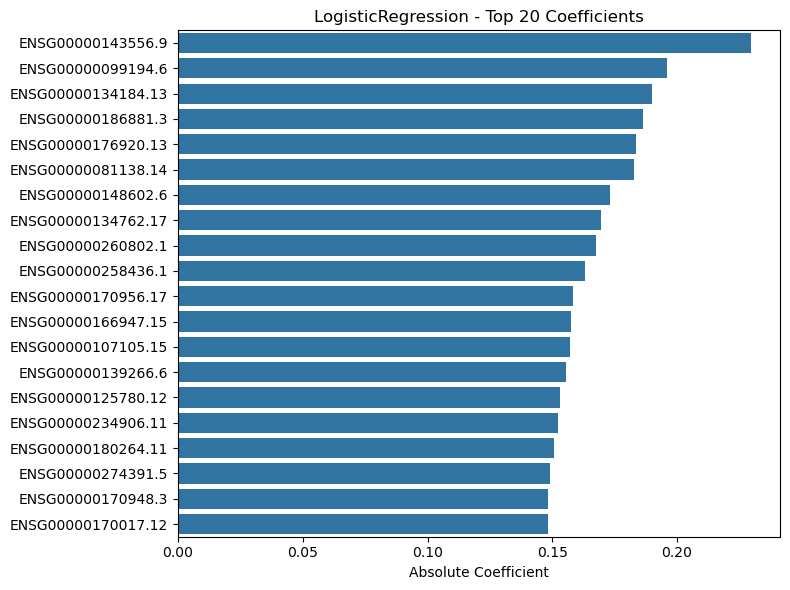

Training XGBoost with Random3000...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [01:58:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [01:59:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:01:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9418
Test Accuracy: 0.9777


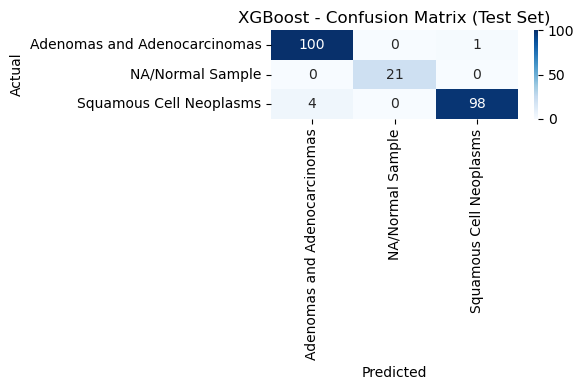

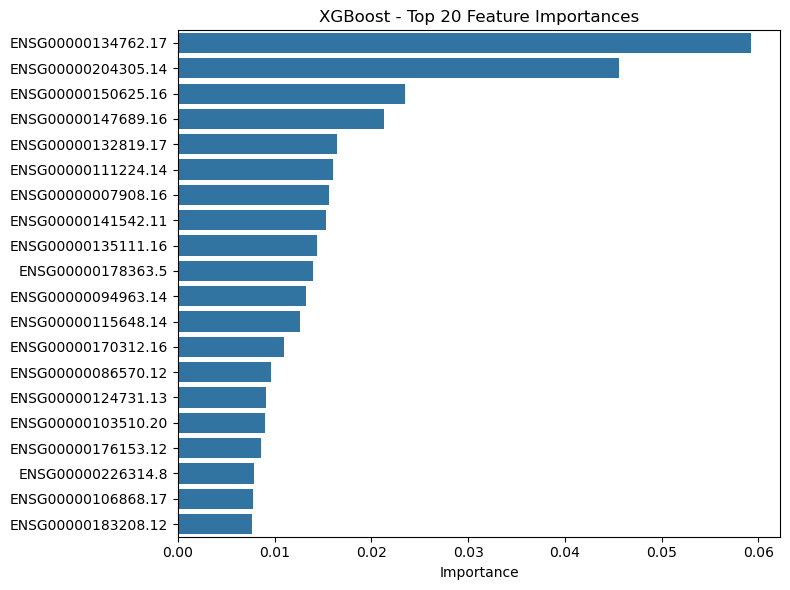

Training SVM with Significant...

SVM - Metrics:
CV Accuracy: 0.9541
Test Accuracy: 0.9777


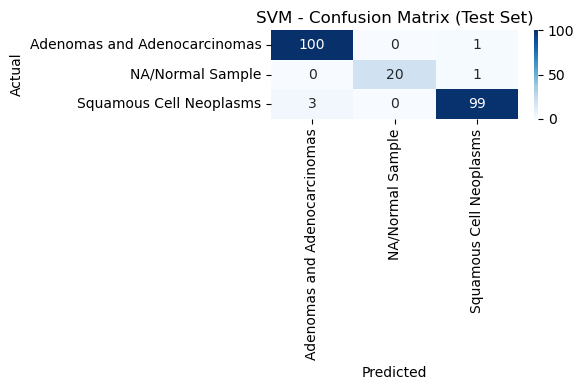

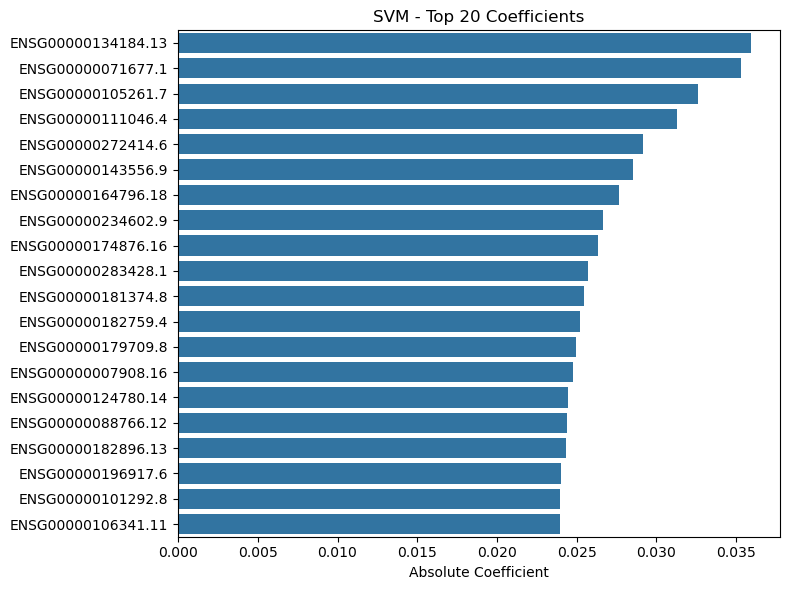

Training LogisticRegression with Significant...

LogisticRegression - Metrics:
CV Accuracy: 0.9530
Test Accuracy: 0.9732


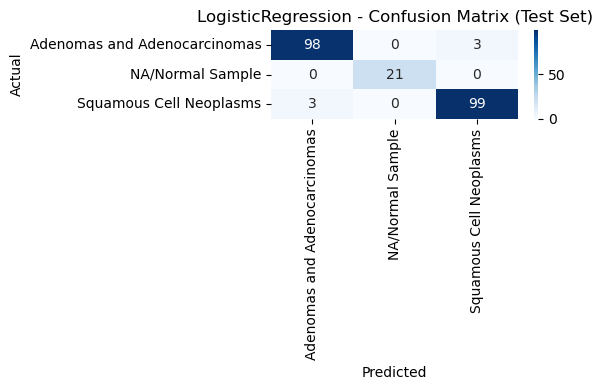

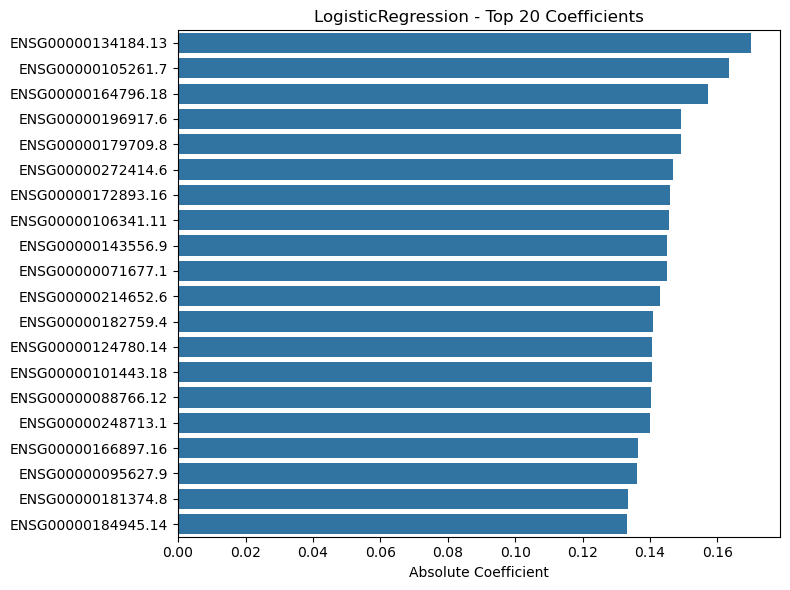

Training XGBoost with Significant...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:07:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:07:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:07:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9777


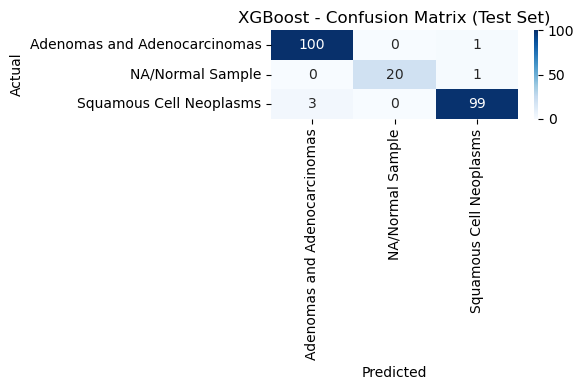

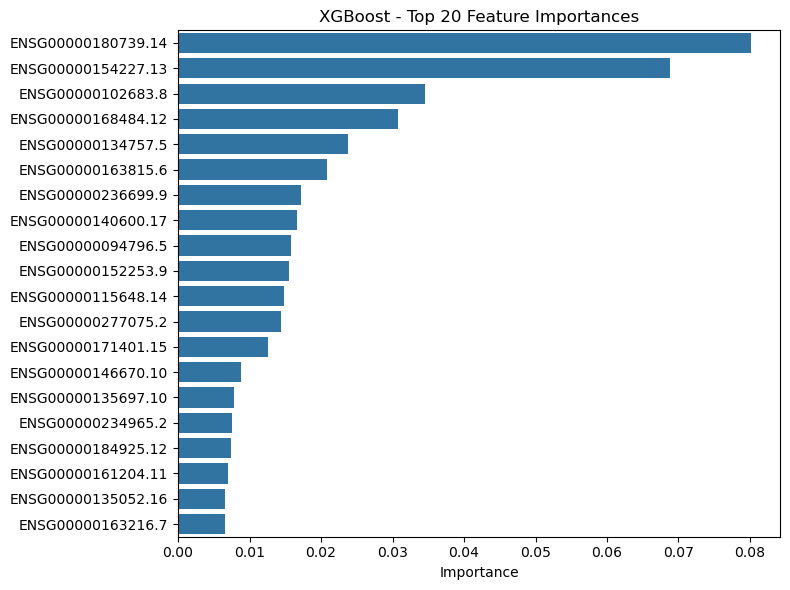

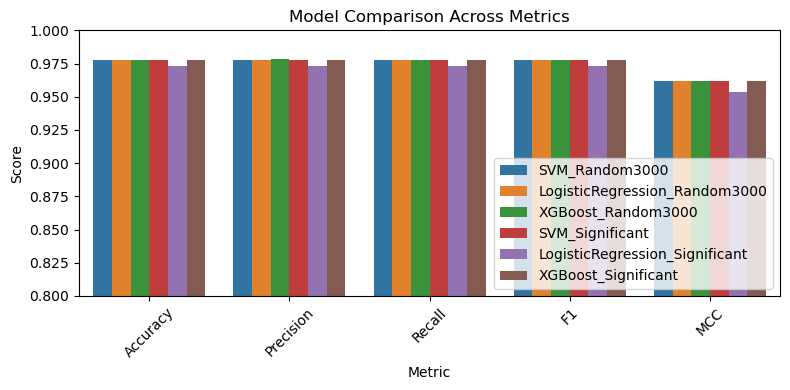

In [ ]:
# With cross validation on 3000 random vs significant genes - corrected for fit transform

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ----------------------- 1. Preprocessing -----------------------
def preprocess_data(df, label_col='cases.disease_type', scaler=None, fit_scaler=True):
    y = df[label_col]
    X = df.drop(columns=[label_col])

    X_log = np.log1p(X)

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_scaled = scaler.fit_transform(X_log)
    else:
        X_scaled = scaler.transform(X_log)

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    return X_scaled, y_encoded, scaler, label_encoder

# ----------------------- 2. Feature Selection -----------------------
def select_random_genes(df, num_genes=3000, seed=42):
    all_genes = df.columns.drop('cases.disease_type')
    return random.sample(list(all_genes), num_genes)

def select_significant_genes(df, gene_list):
    all_genes = df.columns.drop('cases.disease_type')
    return [gene for gene in gene_list if gene in all_genes]

# ----------------------- 3. Training & Evaluation -----------------------
def evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names=None):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validated predictions on training data
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf)

    # Train final model and test on external test set
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    def get_metrics(y_true, y_pred):
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'ConfusionMatrix': confusion_matrix(y_true, y_pred)
        }

    results = {
        'CV': get_metrics(y_train, y_pred_cv),
        'Test': get_metrics(y_test, y_pred_test)
    }

    # Print the accuracy scores for each model
    print(f"\n{name} - Metrics:")   
    print(f"CV Accuracy: {results['CV']['Accuracy']:.4f}")
    print(f"Test Accuracy: {results['Test']['Accuracy']:.4f}")

    # Confusion matrix on test set
    cm = results['Test']['ConfusionMatrix']
    decoded_labels = label_encoder.inverse_transform(np.unique(y_test))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=decoded_labels, yticklabels=decoded_labels)
    plt.title(f'{name} - Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Feature importance plot
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-20:][::-1]  # Top 20
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Feature Importances')
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_') and feature_names is not None:
        # Logistic regression - sum absolute coefficients across classes
        importances = np.abs(model.coef_).sum(axis=0)  # Changed from flatten()
        indices = np.argsort(importances)[-20:][::-1]
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Coefficients')
        plt.xlabel("Absolute Coefficient")
        plt.tight_layout()
        plt.show()

    return results

def train_and_evaluate_models(X_train, y_train, X_test, y_test, label_encoder, gene_set_label, feature_names):
    models = {
        'SVM': SVC(kernel='linear', probability=True),        
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                 random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    }

    all_results = {}
    for name, model in models.items():
        print(f"Training {name} with {gene_set_label}...")
        results = evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names)
        all_results[f"{name}_{gene_set_label}"] = results['Test']  # Save only test results

    return all_results

# ----------------------- 4. Pipeline -----------------------
def run_pipeline(train_csv, test_csv, significant_genes_file):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    with open(significant_genes_file, "r") as f:
        sig_gene_list = [line.strip() for line in f]
    print(train_df['cases.disease_type'].value_counts(normalize=True))
    print(test_df['cases.disease_type'].value_counts(normalize=True))
    #common = pd.merge(train_df, test_df, on='Unnamed: 0', how='inner')
    #print(f"Overlap rows: {len(common)}")


    # Random gene set
    rand_genes = select_random_genes(train_df, 3000)
    train_rand = train_df[['cases.disease_type'] + rand_genes]
    test_rand = test_df[['cases.disease_type'] + rand_genes]
    # Fit scaler on training data only
    X_train_rand, y_train_rand, scaler_rand, le_rand = preprocess_data(train_rand)
    # Use the same scaler for test data (no fitting)
    X_test_rand, y_test_rand, _, _ = preprocess_data(test_rand, scaler=scaler_rand, fit_scaler=False)
    results_random = train_and_evaluate_models(X_train_rand, y_train_rand, X_test_rand, y_test_rand, le_rand, 'Random3000', rand_genes)

    # Significant gene set
    sig_genes = select_significant_genes(train_df, sig_gene_list)
    train_sig = train_df[['cases.disease_type'] + sig_genes]
    test_sig = test_df[['cases.disease_type'] + sig_genes]
    # Fit scaler on training data only
    X_train_sig, y_train_sig, scaler_sig, le_sig = preprocess_data(train_sig)
    # Use the same scaler for test data (no fitting)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig, scaler=scaler_sig, fit_scaler=False)
    results_significant = train_and_evaluate_models(X_train_sig, y_train_sig, X_test_sig, y_test_sig, le_sig, 'Significant', sig_genes)

    return results_random, results_significant

# ----------------------- 5. Comparison Plot -----------------------
def plot_comparison(results_random, results_significant):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
    df = []

    for model_label, metrics_dict in {**results_random, **results_significant}.items():
        for metric in metrics:
            df.append({
                'Model': model_label,
                'Metric': metric,
                'Score': metrics_dict[metric]
            })

    df = pd.DataFrame(df)
    plt.figure(figsize=(8, 4))  # Smaller figure
    sns.barplot(data=df, x='Metric', y='Score', hue='Model')
    plt.title('Model Comparison Across Metrics')
    plt.xticks(rotation=45)
    plt.ylim(0.80, 1.00)  # Zoom in on the top
    plt.legend(loc='lower right')  # Legend in bottom right
    plt.tight_layout()
    plt.show()
    
# ----------------------- 6. Run everything -----------------------
if __name__ == "__main__":
    train_csv = "Data/compiled_train.csv"
    test_csv = "Data/compiled_test.csv"
    sig_genes_file = "Data/intersection_sig_genes.txt"

    results_random, results_significant = run_pipeline(train_csv, test_csv, sig_genes_file)
    plot_comparison(results_random, results_significant)


Training RandomForest with Insignificant...

RandomForest - Metrics:
CV Accuracy: 0.9318
Test Accuracy: 0.9554


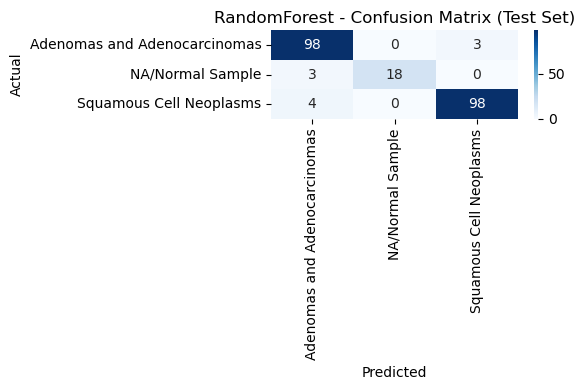

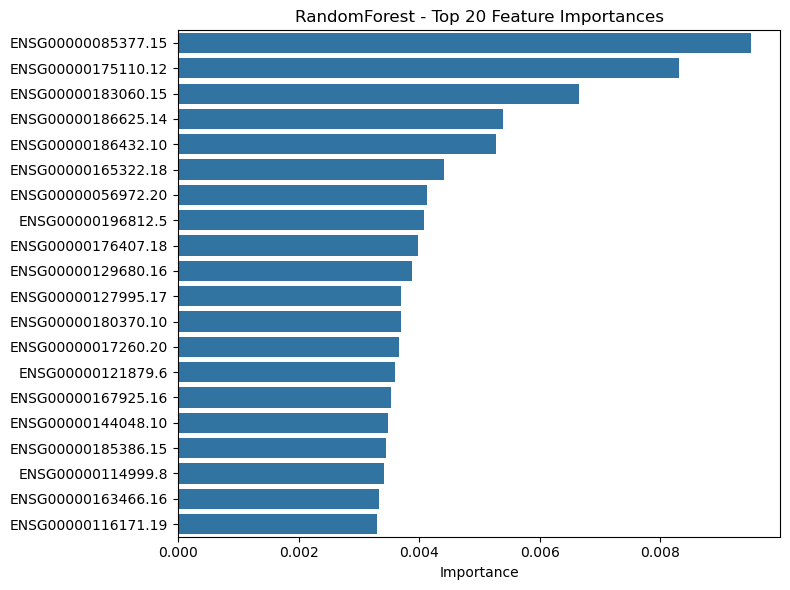

Training LogisticRegression with Insignificant...

LogisticRegression - Metrics:
CV Accuracy: 0.9418
Test Accuracy: 0.9732


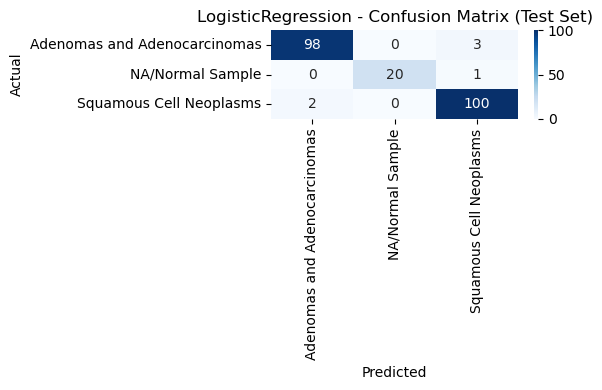

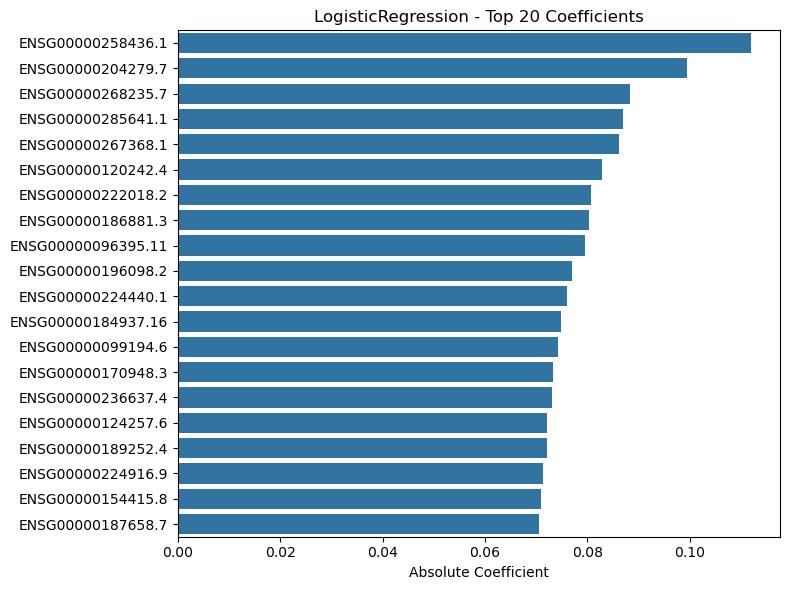

Training XGBoost with Insignificant...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:38:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:40:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:41:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9351
Test Accuracy: 0.9732


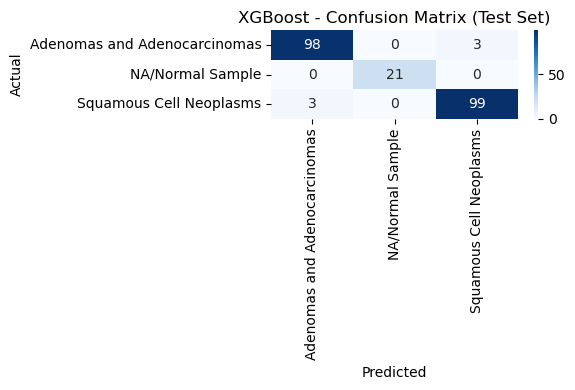

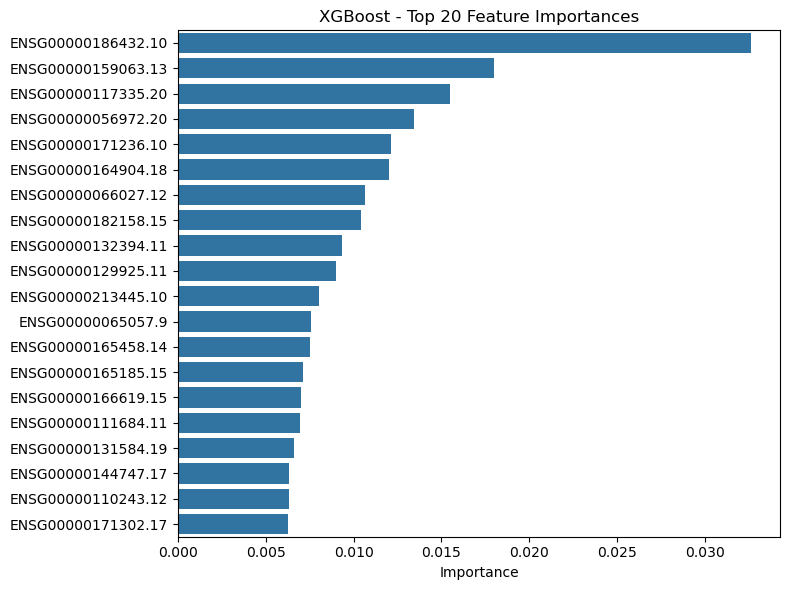

Training RandomForest with Significant...

RandomForest - Metrics:
CV Accuracy: 0.9407
Test Accuracy: 0.9732


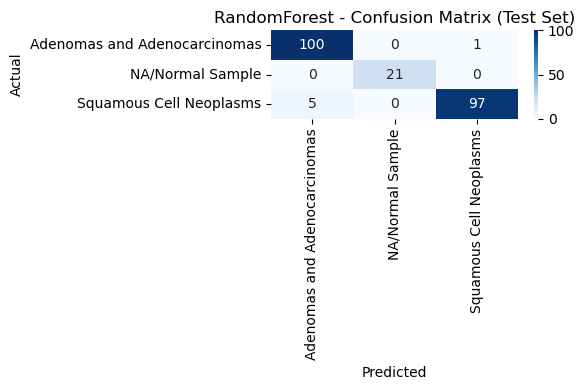

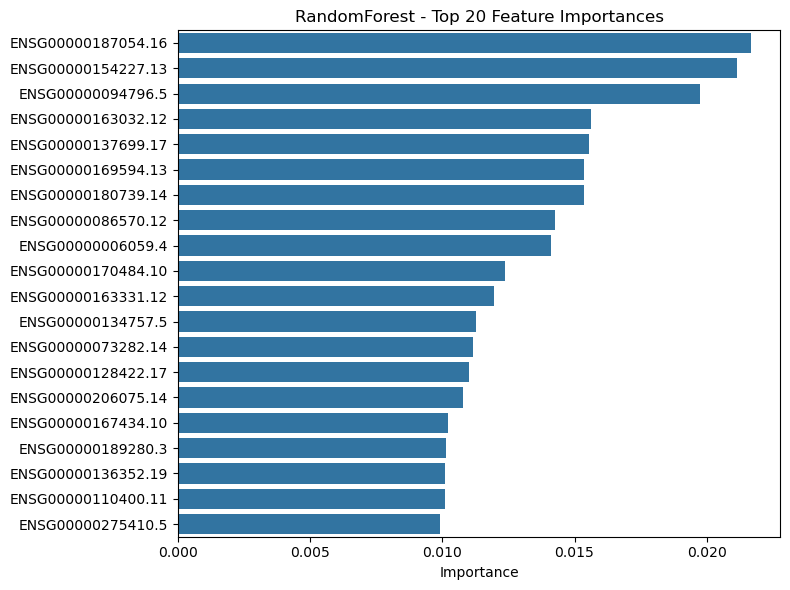

Training LogisticRegression with Significant...

LogisticRegression - Metrics:
CV Accuracy: 0.9530
Test Accuracy: 0.9732


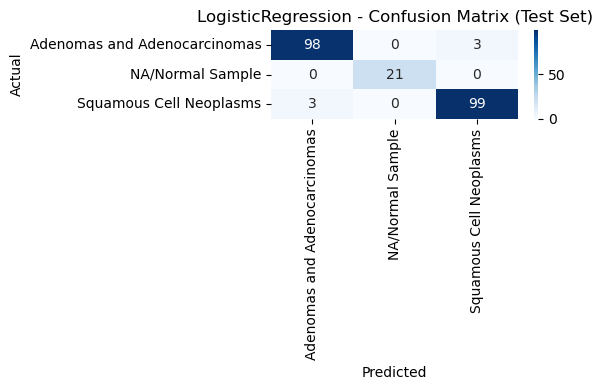

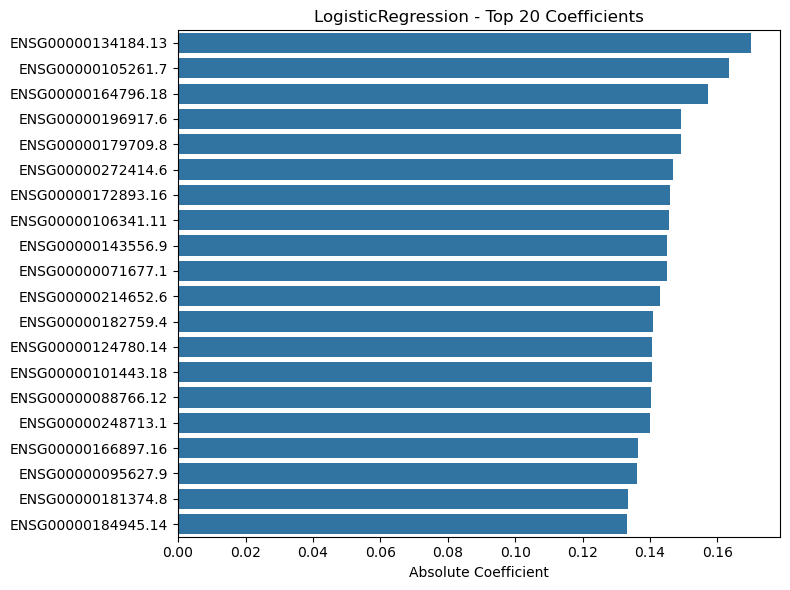

Training XGBoost with Significant...


c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:47:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:47:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [02:47:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Sanchitha\anaconda3\li


XGBoost - Metrics:
CV Accuracy: 0.9485
Test Accuracy: 0.9777


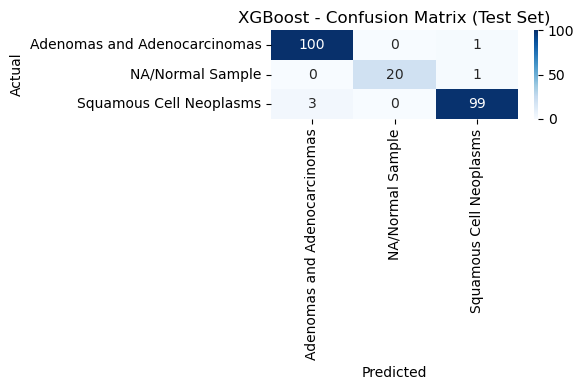

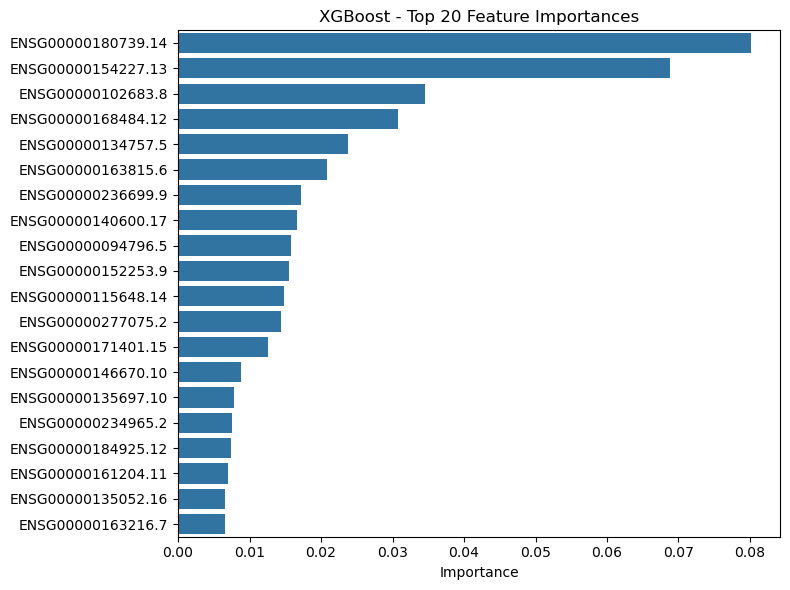

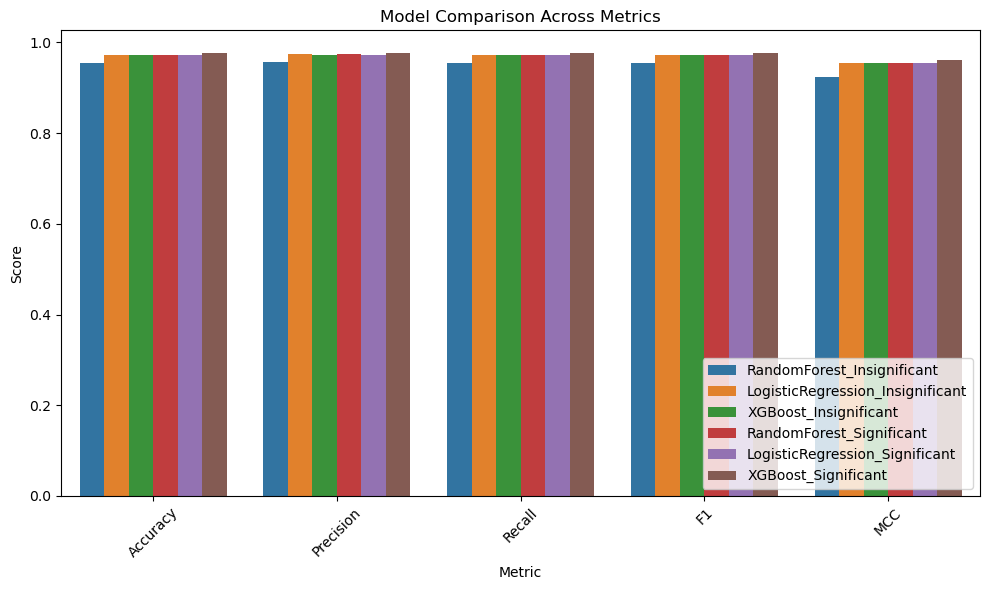

In [22]:
# With cross validation on nonsignificant genes vs significant genes - corrected for fit.transform

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ----------------------- 1. Preprocessing -----------------------
def preprocess_data(df, label_col='cases.disease_type', scaler=None, fit_scaler=True):
    y = df[label_col]
    X = df.drop(columns=[label_col])

    X_log = np.log1p(X)

    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_scaled = scaler.fit_transform(X_log)
    else:
        X_scaled = scaler.transform(X_log)

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    return X_scaled, y_encoded, scaler, label_encoder

# ----------------------- 2. Feature Selection -----------------------
def select_nonsignificant_genes(df, gene_list):
    all_genes = df.columns.drop('cases.disease_type')
    #return [gene for gene not in gene_list if gene in all_genes]
    return [gene for gene in all_genes if gene not in gene_list]

def select_significant_genes(df, gene_list):
    all_genes = df.columns.drop('cases.disease_type')
    return [gene for gene in gene_list if gene in all_genes]

# ----------------------- 3. Training & Evaluation -----------------------
def evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names=None):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validated predictions on training data
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=skf)

    # Train final model and test on external test set
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    def get_metrics(y_true, y_pred):
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'ConfusionMatrix': confusion_matrix(y_true, y_pred)
        }

    results = {
        'CV': get_metrics(y_train, y_pred_cv),
        'Test': get_metrics(y_test, y_pred_test)
    }

    # Print the accuracy scores for each model
    print(f"\n{name} - Metrics:")   
    print(f"CV Accuracy: {results['CV']['Accuracy']:.4f}")
    print(f"Test Accuracy: {results['Test']['Accuracy']:.4f}")

    # Confusion matrix on test set
    cm = results['Test']['ConfusionMatrix']
    decoded_labels = label_encoder.inverse_transform(np.unique(y_test))
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=decoded_labels, yticklabels=decoded_labels)
    plt.title(f'{name} - Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Feature importance plot
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-20:][::-1]  # Top 20
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Feature Importances')
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_') and feature_names is not None:
        # Logistic regression - sum absolute coefficients across classes
        importances = np.abs(model.coef_).sum(axis=0)  # Changed from flatten()
        indices = np.argsort(importances)[-20:][::-1]
        """# Logistic regression
        importances = np.abs(model.coef_).flatten()
        indices = np.argsort(importances)[-20:][::-1]"""
        plt.figure(figsize=(8, 6))
        sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
        plt.title(f'{name} - Top 20 Coefficients')
        plt.xlabel("Absolute Coefficient")
        plt.tight_layout()
        plt.show()

    return results

def train_and_evaluate_models(X_train, y_train, X_test, y_test, label_encoder, gene_set_label, feature_names):
    models = {
        'RandomForest': RandomForestClassifier(random_state=42),
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                 random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    }

    all_results = {}
    for name, model in models.items():
        print(f"Training {name} with {gene_set_label}...")
        results = evaluate_model(name, model, X_train, y_train, X_test, y_test, label_encoder, feature_names)
        all_results[f"{name}_{gene_set_label}"] = results['Test']  # Save only test results

    return all_results

# ----------------------- 4. Pipeline -----------------------
def run_pipeline(train_csv, test_csv, significant_genes_file, any_significant_genes_file):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    with open(significant_genes_file, "r") as f:
        sig_gene_list = [line.strip() for line in f]
    with open(any_significant_genes_file, "r") as f:
        any_sig_gene_list = [line.strip() for line in f]

    # Random gene set
    non_sig_genes = select_nonsignificant_genes(train_df, any_sig_gene_list)
    #all_genes = train_df.columns.drop('cases.disease_type')
    train_non_sig = train_df[['cases.disease_type'] + non_sig_genes]
    test_non_sig = test_df[['cases.disease_type'] + non_sig_genes]
    """X_train_non_sig, y_train_non_sig, _, le_non_sig = preprocess_data(train_non_sig)
    X_test_non_sig, y_test_non_sig, _, _ = preprocess_data(test_non_sig)"""
    # Fit scaler on training data only
    X_train_non_sig, y_train_non_sig, scaler_non_sig, le_non_sig = preprocess_data(train_non_sig)
    # Use the same scaler for test data (no fitting)
    X_test_non_sig, y_test_non_sig, _, _ = preprocess_data(test_non_sig, scaler=scaler_non_sig, fit_scaler=False)
    results_non_sig = train_and_evaluate_models(X_train_non_sig, y_train_non_sig, X_test_non_sig, y_test_non_sig, le_non_sig, 'Insignificant', non_sig_genes)

    # Significant gene set
    sig_genes = select_significant_genes(train_df, sig_gene_list)
    train_sig = train_df[['cases.disease_type'] + sig_genes]
    test_sig = test_df[['cases.disease_type'] + sig_genes]
    # Fit scaler on training data only
    X_train_sig, y_train_sig, scaler_sig, le_sig = preprocess_data(train_sig)
    # Use the same scaler for test data (no fitting)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig, scaler=scaler_sig, fit_scaler=False)
    """ X_train_sig, y_train_sig, _, le_sig = preprocess_data(train_sig)
    X_test_sig, y_test_sig, _, _ = preprocess_data(test_sig)"""
    results_significant = train_and_evaluate_models(X_train_sig, y_train_sig, X_test_sig, y_test_sig, le_sig, 'Significant', sig_genes)

    return results_non_sig, results_significant

# ----------------------- 5. Comparison Plot -----------------------
def plot_comparison(results_random, results_significant):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
    df = []

    for model_label, metrics_dict in {**results_random, **results_significant}.items():
        for metric in metrics:
            df.append({
                'Model': model_label,
                'Metric': metric,
                'Score': metrics_dict[metric]
            })

    df = pd.DataFrame(df)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='Metric', y='Score', hue='Model')
    plt.title('Model Comparison Across Metrics')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend(loc='lower right')
    plt.show()

# ----------------------- 6. Run everything -----------------------
if __name__ == "__main__":
    train_csv = "Data/compiled_train.csv"
    test_csv = "Data/compiled_test.csv"
    sig_genes_file = "Data/intersection_sig_genes.txt"
    any_sig_genes_file = "Data/union_sig_genes.txt"

    results_non_sig, results_significant = run_pipeline(train_csv, test_csv, sig_genes_file, any_sig_genes_file)
    plot_comparison(results_non_sig, results_significant)
